In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score,mean_squared_error

In [3]:
final_table = pd.read_csv('final_table.csv',index_col = 0)
final_table.shape

(85426, 7)

In [4]:
final_table.dropna(inplace=True)
final_table.shape

(44980, 7)

In [5]:
final_table['Area'].nunique()

200

In [6]:
final_table['Item'].nunique()

157

In [7]:
from sklearn.model_selection import train_test_split

# Isolate columns from our 44,986 clean records
X = final_table[['Year', 'Area', 'Item', 'Area_Harvested_ha', 'Yield_kg_ha']]
y = final_table['Production_tons']

# Step 1: Separate the 20% final holdout Test vault
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Step 2: Split the remainder into Train (60%) and Validation (20%)
X_train, X_validate, y_train, y_validate = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print("📂 SPLIT COMPLETION REGISTER:")
print(f"• Training Pool (60%):   {X_train.shape[0]} rows")
print(f"• Validation Pool (20%): {X_validate.shape[0]} rows")
print(f"• Holdout Test Pool (20%): {X_test.shape[0]} rows")

📂 SPLIT COMPLETION REGISTER:
• Training Pool (60%):   26988 rows
• Validation Pool (20%): 8996 rows
• Holdout Test Pool (20%): 8996 rows


In [8]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, TargetEncoder

# 1. Define column groups
numeric_cols = ['Year', 'Area_Harvested_ha', 'Yield_kg_ha']
categorical_cols = ['Area', 'Item']

# 2. Create updated preprocessor
# cv=5 and smooth="auto" inside TargetEncoder prevent target leakage and overfitting!
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', TargetEncoder(smooth="auto", cv=5), categorical_cols)
    ]
)

# 3. Fit on X_train and y_train (TargetEncoder NEEDS y_train!)
X_train_transformed = preprocessor.fit_transform(X_train, y_train)
X_validate_transformed = preprocessor.transform(X_validate)
X_test_transformed = preprocessor.transform(X_test)

# print(f"Features after Target Encoding: {X_train_transformed.shape[1]} columns!")
# Output: Features after Target Encoding: 5 columns!

In [9]:
# Get feature names
all_column_names = preprocessor.get_feature_names_out()

In [10]:
all_column_names

array(['num__Year', 'num__Area_Harvested_ha', 'num__Yield_kg_ha',
       'cat__Area', 'cat__Item'], dtype=object)

In [11]:
# Reconstruct clean feature DataFrames (No .toarray() needed!)
X_train_df = pd.DataFrame(X_train_transformed, columns=all_column_names)
X_val_df = pd.DataFrame(X_validate_transformed, columns=all_column_names)
X_test_df = pd.DataFrame(X_test_transformed, columns=all_column_names)

print(f"✅ Preprocessing Complete! Reduced features down to {X_train_df.shape[1]} dense columns.\n")

✅ Preprocessing Complete! Reduced features down to 5 dense columns.



In [23]:
# ==========================================
# 3. RANDOM FOREST REGRESSOR
# ==========================================
print("🏋️ Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
rf_model.fit(X_train_df, y_train)

# Predictions
rf_train_preds = rf_model.predict(X_train_df)
rf_val_preds = rf_model.predict(X_val_df)
rf_test_preds = rf_model.predict(X_test_df)

# Calculate Metrics
# Training Loss (MSE)
rf_train_mse = np.sqrt(mean_squared_error(y_train, rf_train_preds))

# Validation Metrics (RMSE & R²)
rf_val_rmse = np.sqrt(mean_squared_error(y_validate, rf_val_preds))
rf_val_r2 = r2_score(y_validate, rf_val_preds)

# Holdout Test Metrics (RMSE & R²)
rf_test_rmse = np.sqrt(mean_squared_error(y_test, rf_test_preds))
rf_test_r2 = r2_score(y_test, rf_test_preds)

print("==========================================================================")
print("🛡️ RANDOM FOREST PERFORMANCE EVALUATION")
print("==========================================================================")
print(f"• Training Set Loss (RMSE):       {rf_train_mse:,.2f}")
print("--------------------------------------------------------------------------")
print(f"• Validation Set RMSE (Tons):   {rf_val_rmse:,.2f}")
print(f"• Validation Set R²:            {rf_val_r2:.4f}")
print("--------------------------------------------------------------------------")
print(f"• Holdout Test Set RMSE (Tons): {rf_test_rmse:,.2f}")
print(f"• Holdout Test Set R²:          {rf_test_r2:.4f}")
print("==========================================================================\n")

🏋️ Training Random Forest Regressor...
🛡️ RANDOM FOREST PERFORMANCE EVALUATION
• Training Set Loss (RMSE):       1,351,379.30
--------------------------------------------------------------------------
• Validation Set RMSE (Tons):   2,189,583.52
• Validation Set R²:            0.9521
--------------------------------------------------------------------------
• Holdout Test Set RMSE (Tons): 2,324,240.36
• Holdout Test Set R²:          0.9515



In [13]:
# Reconstruct diagnostic test DataFrame
test_rf_df = X_test_df.copy()
test_rf_df['Target_Actual_Tons'] = y_test.values
test_rf_df['Model_Predicted_Tons'] = rf_test_preds

In [14]:
test_rf_df

,num__Year,num__Area_Harvested_ha,num__Yield_kg_ha,cat__Area,cat__Item,Target_Actual_Tons,Model_Predicted_Tons
0,0.706544,0.214249,-0.446800,881817.112376,2.287320e+05,271979.00,261325.0780
1,-1.422951,-0.104895,-0.446997,702743.448514,3.601264e+04,13828.29,13754.6938
2,-1.422951,-0.122026,0.447973,3947.052199,8.598285e+05,5392.50,5473.8184
3,-1.422951,-0.121925,-0.227016,41585.067188,1.121487e+05,2400.01,2390.3250
4,-0.713119,-0.120022,0.451427,497452.252794,3.463981e+06,79979.75,79153.1898
...,...,...,...,...,...,...,...
8991,0.706544,-0.094071,-0.018967,849299.199594,1.964584e+05,509781.46,503735.5262
8992,-1.422951,-0.053718,-0.275241,343421.440445,9.378151e+05,531122.00,530739.1476
8993,-0.713119,-0.072412,-0.454886,232955.306848,1.968487e+04,23931.00,23085.1658
8994,0.706544,-0.122020,-0.048092,1123.784341,2.404091e+06,2568.52,2572.4322


In [24]:
# ==========================================
# 4. LINEAR REGRESSION (RIDGE BASELINE)
# ==========================================
print("🏋️ Training baseline Linear Regression (Ridge) model...")
lr_model = Ridge(alpha=1.0)
lr_model.fit(X_train_df, y_train)

# Predictions
lr_train_preds = lr_model.predict(X_train_df)
lr_val_preds = lr_model.predict(X_val_df)
lr_test_preds = lr_model.predict(X_test_df)

# Calculate Metrics
# Training Loss (MSE)
lr_train_mse = np.sqrt(mean_squared_error(y_train, lr_train_preds))

# Validation Metrics (RMSE & R²)
lr_val_rmse = np.sqrt(mean_squared_error(y_validate, lr_val_preds))
lr_val_r2 = r2_score(y_validate, lr_val_preds)

# Holdout Test Metrics (RMSE & R²)
lr_test_rmse = np.sqrt(mean_squared_error(y_test, lr_test_preds))
lr_test_r2 = r2_score(y_test, lr_test_preds)

print("==========================================================================")
print("📉 LINEAR REGRESSION PERFORMANCE EVALUATION")
print("==========================================================================")
print(f"• Training Set Loss (RMSE):       {lr_train_mse:,.2f}")
print("--------------------------------------------------------------------------")
print(f"• Validation Set RMSE (Tons):   {lr_val_rmse:,.2f}")
print(f"• Validation Set R²:            {lr_val_r2:.4f}")
print("--------------------------------------------------------------------------")
print(f"• Holdout Test Set RMSE (Tons): {lr_test_rmse:,.2f}")
print(f"• Holdout Test Set R²:          {lr_test_r2:.4f}")
print("==========================================================================\n")

🏋️ Training baseline Linear Regression (Ridge) model...
📉 LINEAR REGRESSION PERFORMANCE EVALUATION
• Training Set Loss (RMSE):       11,247,107.11
--------------------------------------------------------------------------
• Validation Set RMSE (Tons):   7,113,693.54
• Validation Set R²:            0.4942
--------------------------------------------------------------------------
• Holdout Test Set RMSE (Tons): 7,568,039.78
• Holdout Test Set R²:          0.4861



In [16]:
# Reconstruct diagnostic test DataFrame for Ridge
test_lr_df = X_test_df.copy()
test_lr_df['Target_Actual_Tons'] = y_test.values
test_lr_df['Model_Predicted_Tons'] = lr_test_preds

In [17]:
test_lr_df

,num__Year,num__Area_Harvested_ha,num__Yield_kg_ha,cat__Area,cat__Item,Target_Actual_Tons,Model_Predicted_Tons
0,0.706544,0.214249,-0.446800,881817.112376,2.287320e+05,271979.00,2.145464e+06
1,-1.422951,-0.104895,-0.446997,702743.448514,3.601264e+04,13828.29,-7.667605e+05
2,-1.422951,-0.122026,0.447973,3947.052199,8.598285e+05,5392.50,-1.083646e+05
3,-1.422951,-0.121925,-0.227016,41585.067188,1.121487e+05,2400.01,-9.822657e+05
4,-0.713119,-0.120022,0.451427,497452.252794,3.463981e+06,79979.75,1.422847e+06
...,...,...,...,...,...,...,...
8991,0.706544,-0.094071,-0.018967,849299.199594,1.964584e+05,509781.46,-2.298155e+05
8992,-1.422951,-0.053718,-0.275241,343421.440445,9.378151e+05,531122.00,1.136791e+05
8993,-0.713119,-0.072412,-0.454886,232955.306848,1.968487e+04,23931.00,-7.019185e+05
8994,0.706544,-0.122020,-0.048092,1123.784341,2.404091e+06,2568.52,2.697073e+05


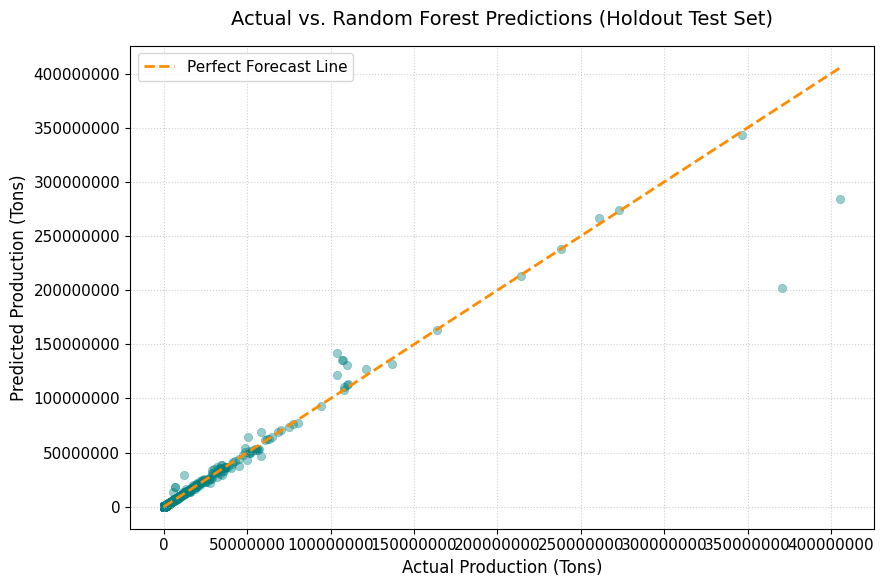

In [18]:
# Shared configuration for clean axis formatting
plt.rcParams.update({'font.size': 11})

# ==========================================
# 5A. RANDOM FOREST VISUALIZATION
# ==========================================
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=test_rf_df['Target_Actual_Tons'], 
    y=test_rf_df['Model_Predicted_Tons'], 
    alpha=0.4, 
    color='teal', 
    edgecolor=None
)

# Reference line for ideal predictions
max_val_rf = max(test_rf_df['Target_Actual_Tons'].max(), test_rf_df['Model_Predicted_Tons'].max())
plt.plot([0, max_val_rf], [0, max_val_rf], color='darkorange', linestyle='--', linewidth=2, label='Perfect Forecast Line')

plt.title('Actual vs. Random Forest Predictions (Holdout Test Set)', fontsize=14, pad=15)
plt.xlabel('Actual Production (Tons)', fontsize=12)
plt.ylabel('Predicted Production (Tons)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')  # Suppresses scientific notation
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

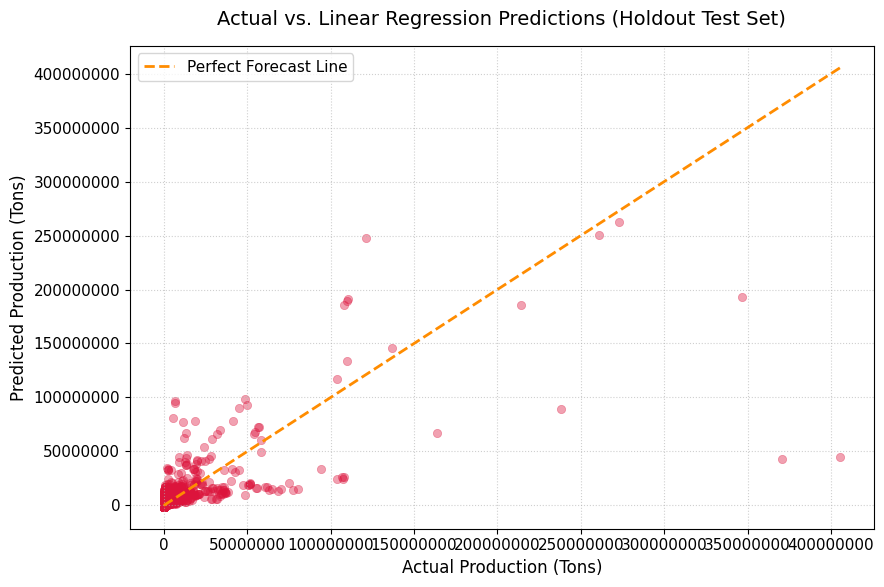

In [19]:
# ==========================================
# 5B. LINEAR REGRESSION VISUALIZATION
# ==========================================
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=test_lr_df['Target_Actual_Tons'], 
    y=test_lr_df['Model_Predicted_Tons'], 
    alpha=0.4, 
    color='crimson', 
    edgecolor=None
)

# Reference line for ideal predictions
max_val_lr = max(test_lr_df['Target_Actual_Tons'].max(), test_lr_df['Model_Predicted_Tons'].max())
plt.plot([0, max_val_lr], [0, max_val_lr], color='darkorange', linestyle='--', linewidth=2, label='Perfect Forecast Line')

plt.title('Actual vs. Linear Regression Predictions (Holdout Test Set)', fontsize=14, pad=15)
plt.xlabel('Actual Production (Tons)', fontsize=12)
plt.ylabel('Predicted Production (Tons)', fontsize=12)
plt.ticklabel_format(style='plain', axis='both')  # Suppresses scientific notation
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()